# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier
import lightgbm as lgb

# Load Dataset

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (594194, 21)
Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


# Dataset Overview

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [4]:
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# target distribution

In [5]:
train['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

Churn
No     460377
Yes    133817
Name: count, dtype: int64


<Axes: xlabel='Churn'>

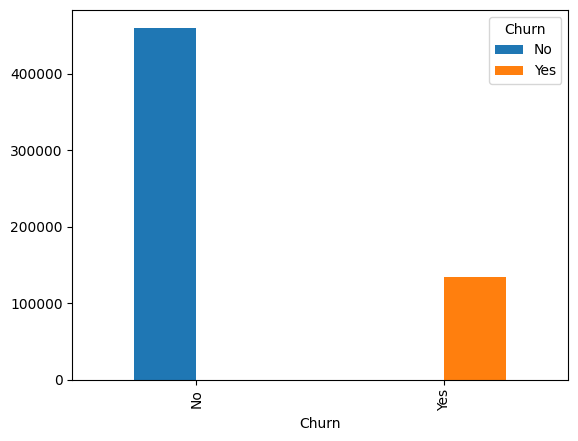

In [6]:
print(train.Churn.value_counts())
pd.crosstab(train.Churn,train.Churn).plot(kind='bar')

# Exploratory Data Analysis

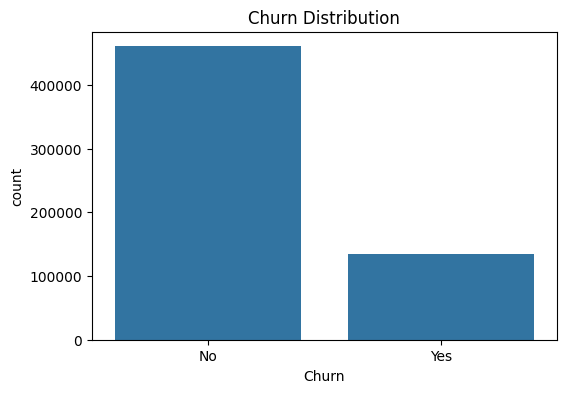

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=train)
plt.title("Churn Distribution")
plt.show()

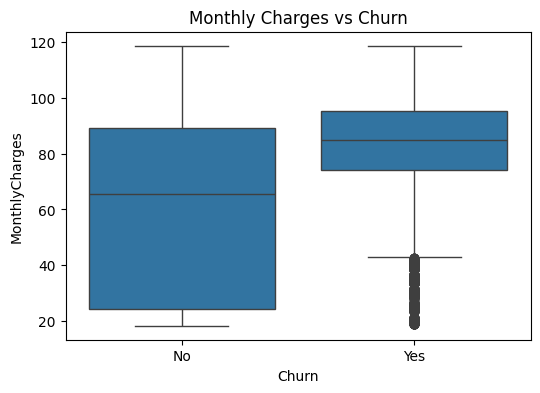

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=train)
plt.title("Monthly Charges vs Churn")
plt.show()

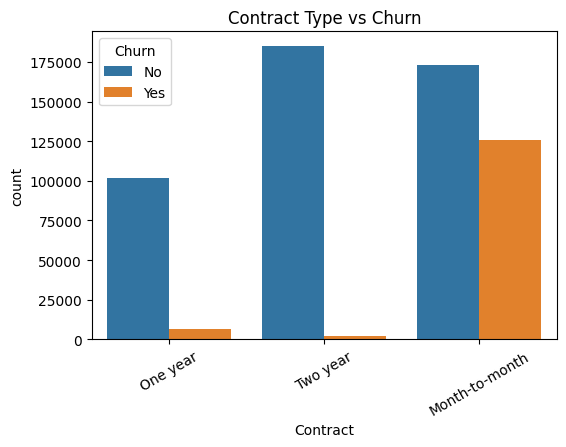

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=train)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=30)
plt.show()

# target and feaature 

In [10]:
y = train['Churn'].map({'Yes':1,'No':0})

x = train.drop(['id','Churn'],axis=1)

x_test = test.drop('id',axis=1)

test_id = test['id']

# Feature Engineering

Feature engineering is one of the most important steps in Kaggle competitions.

We create new features to capture customer behavior.

New features:

avg_spend → Average spend per month

loyalty_label → Customer loyalty groups

services → Number of services used

per_cost → Monthly cost per service

charges_yr → Estimated yearly spending

In [11]:
services = [
'PhoneService','MultipleLines','InternetService',
'OnlineSecurity','OnlineBackup','DeviceProtection',
'TechSupport','StreamingTV','StreamingMovies'
]

def feature_engineering(df):

    df['avg_spend'] = df['TotalCharges'] / df['tenure']

    df['loyalty_label'] = pd.cut(df['tenure'],bins=[0,12,24,48,72],labels=[1,2,3,4])

    df['services'] = df[services].isin(["Yes","DSL","Fiber optic"]).sum(axis=1)

    df['per_cost'] = df['MonthlyCharges'] / (df['services']+1)

    df['charges_yr'] = df['MonthlyCharges'] * 12 / df['tenure']

    return df

x = feature_engineering(x)
x_test = feature_engineering(x_test)

# Categorical Feature Handling

In [12]:
categorical_features = [
'gender','Partner','Dependents','PhoneService','MultipleLines',
'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
'TechSupport','StreamingTV','StreamingMovies','Contract',
'PaperlessBilling','PaymentMethod','loyalty_label'
]

for col in categorical_features:
    x[col] = x[col].astype('category')
    x_test[col] = x_test[col].astype('category')

cat_feature_index = [x.columns.get_loc(col) for col in categorical_features]

# Cross Validation Setup

In [13]:
oof_cat = np.zeros(len(x))
oof_lgb = np.zeros(len(x))

test_cat = np.zeros(len(x_test))
test_lgb = np.zeros(len(x_test))

In [14]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Model Training
We train two models:

CatBoost

LightGBM

In [15]:
for fold,(train_idx,val_idx) in enumerate(skf.split(x,y)):

    print("Fold",fold+1)

    x_train,x_val = x.iloc[train_idx],x.iloc[val_idx]
    y_train,y_val = y.iloc[train_idx],y.iloc[val_idx]

    # CatBoost

    cat_model = CatBoostClassifier(
        iterations=2500,
        learning_rate=0.03,
        depth=7,
        l2_leaf_reg=8,
        loss_function='Logloss',
        eval_metric='AUC',
        task_type='GPU',
        devices='0:1',
        random_seed=42,
        verbose=0
    )

    cat_model.fit(
        x_train,y_train,
        eval_set=(x_val,y_val),
        cat_features=cat_feature_index
    )

    oof_cat[val_idx] = cat_model.predict_proba(x_val)[:,1]

    test_cat += cat_model.predict_proba(x_test)[:,1] / 5


    # LightGBM

    lgb_model = lgb.LGBMClassifier(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=48,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=5,
        objective='binary',
        device='gpu'
    )

    lgb_model.fit(
        x_train,y_train,
        eval_set=[(x_val,y_val)],
        eval_metric='auc',
        categorical_feature=categorical_features,
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    oof_lgb[val_idx] = lgb_model.predict_proba(x_val)[:,1]

    test_lgb += lgb_model.predict_proba(x_test)[:,1] / 5

Fold 1


Default metric period is 5 because AUC is/are not implemented for GPU


[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 24
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 21 dense feature groups (10.88 MB) transferred to GPU in 0.011693 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

...

[LightGBM] [Info] Number of positive: 107053, number of negative: 368302
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 24
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 21 dense feature groups (10.88 MB) transferred to GPU in 0.011256 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225206 -> initscore=-1.235579
[LightGBM] [Info] Start training from score -1.235579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

Default metric period is 5 because AUC is/are not implemented for GPU


[LightGBM] [Info] Number of positive: 107053, number of negative: 368302
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 24
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 21 dense feature groups (10.88 MB) transferred to GPU in 0.011348 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225206 -> initscore=-1.235579
[LightGBM] [Info] Start training from score -1.235579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

Default metric period is 5 because AUC is/are not implemented for GPU


[LightGBM] [Info] Number of positive: 107054, number of negative: 368302
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 475356, number of used features: 24
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 21 dense feature groups (10.88 MB) transferred to GPU in 0.012069 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225208 -> initscore=-1.235570
[LightGBM] [Info] Start training from score -1.235570
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

# Model Ensemble

Combining models often improves performance.

In [16]:
oof_final = 0.65 * oof_cat + 0.35 * oof_lgb

test_final = 0.65 * test_cat + 0.35 * test_lgb

#  Model Performance

In [17]:
print("Final ROC AUC:", roc_auc_score(y, oof_final))

Final ROC AUC: 0.9163936568330807


# Create Submission

In [18]:
submission = pd.DataFrame({
    'id': test_id,
    'Churn': test_final
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,Churn
0,594194,0.070740
1,594195,0.001085
2,594196,0.102360
3,594197,0.003457
4,594198,0.480144


# Conclusion

Key takeaways:

Feature engineering significantly improves model performance

CatBoost handles categorical features very well

LightGBM is extremely fast and powerful

Ensembling models improves robustness

Final CV Score: ~0.91+ AUC

# If You Found This Notebook Helpful

If this notebook helped you learn something new, please consider upvoting.

It motivates me to create more Kaggle notebooks.